# Introduction to Audio Data Manipulation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://drive.google.com/file/d/1q01X1M23pAU3IbvCUMf3dQaRzwmuHbfh/view?usp=sharing)

This notebook demonstrates how to use the OpenAI Whisper model for Speech-to-Text (STT) transcription. We will download a 'fast' version of the model, load it, and then perform inference on an audio file.

Note: Speech-to-Text (STT) is sometimes referred to as Automatic Speech Recognition (ASR). These two terms can be used interchangeably.

# Record Audio From Microphone

In [25]:
import sounddevice as sd
import numpy as np

duration = 3  # seconds
sampling_rate = 16000  # Hz
dtype = np.int16  # bit depth

recording = sd.rec(
    duration * sampling_rate,
    samplerate=sampling_rate,
    channels=1,
    dtype=dtype,
)

print("Recording...")
sd.wait()  # Wait until the recording is finished
print("Recording finished.")

Recording...
Recording finished.


In [26]:
print("audio data shape:", recording.shape)
print(recording[-10:])  # Print the last 10 samples of the recording

audio data shape: (48000, 1)
[[230]
 [217]
 [244]
 [250]
 [251]
 [233]
 [210]
 [185]
 [142]
 [120]]


In [27]:
sd.play(recording, samplerate=sampling_rate)

# Visualize Waveform and Spectrogram

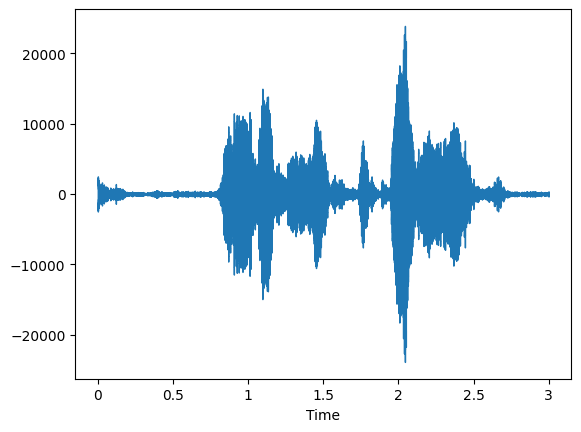

In [29]:
import librosa
import matplotlib.pyplot as plt

librosa.display.waveshow(recording.flatten().astype(np.float32), sr=sampling_rate)

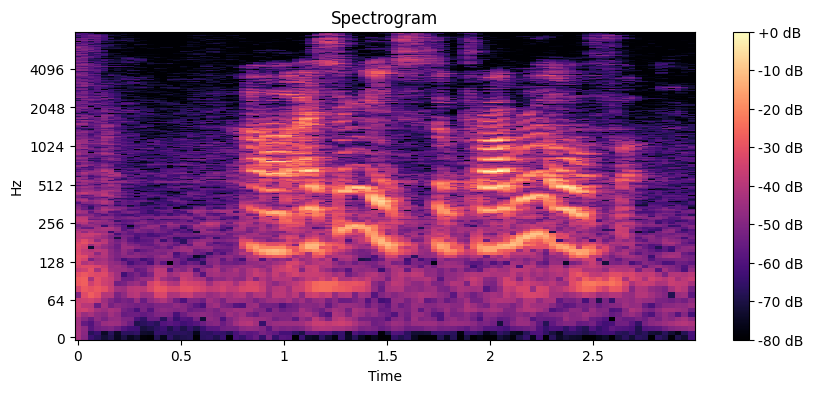

In [33]:
import numpy as np

frequencies = np.abs(librosa.stft(recording.flatten().astype(np.float32)))
D = librosa.amplitude_to_db(frequencies, ref=np.max)
plt.figure(figsize=(10, 4))
librosa.display.specshow(D, sr=sampling_rate, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.show()

# Load and Write Audio File

In [34]:
import soundfile as sf

sf.write("recoding.wav", recording, sampling_rate, subtype="PCM_16")

In [35]:
recording, sampling_rate = sf.read("recoding.wav")
print(recording.shape, sampling_rate)

(48000,) 16000


# Resample

In [13]:
resampled_rate = 16000
resampled_recording = librosa.resample(
    recording.flatten(), orig_sr=sampling_rate, target_sr=resampled_rate
)
print(resampled_recording.shape)

(80000,)


In [14]:
sd.play(resampled_recording, samplerate=resampled_rate)